In [1]:
# Block 1: imports, parameters, and generic PDP Gaussian calibration

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 1. Basic simulation inputs
# ---------------------------
rng = np.random.default_rng(20260327)

n = 1000                  # sample size
R = 5000                  # Monte Carlo replications
T_Omega = 4.0             # fixed trace tr(Omega_p)
eps = 1.0                 # PDP privacy level epsilon

def clipping_bound_from_trace(trace_Omega):
    return 2.0 * np.sqrt(trace_Omega)


B = clipping_bound_from_trace(T_Omega)  # = 3 * sqrt(tr(Omega_p)) under the fixed-trace setup

# Lambdas to compare
lambdas = [-0.5, 1.0, 2.0]

# Dense dimension grid: set p manually here
# p_grid = [5,10,20,50, 100, 200, 300, 500]
p_grid = np.arange(5,51,dtype=int)

# Covariance-design parameters
rho_ar1 = 0.7
a_het = 2.0   # largest diagonal variance / smallest diagonal variance = 2

# ---------------------------
# 2. Sensitivity of the clipped sample mean
# ---------------------------
def delta_l2_mean(B, n):
    """
    L2 sensitivity of the clipped sample mean:
        Delta_{L2}(Xbar) = 2B / n
    """
    return 2.0 * B / n


# ---------------------------
# 3. Generic PDP Gaussian calibration
# ---------------------------
def kappa_lambda_epsilon(lam, eps):
    """
    Generic PDP calibration constant kappa_{lambda, eps} from Theorem 4.

    For admissible (lambda, eps):
        kappa_{lambda, eps} =
            2 * log(1 + lambda*(lambda+1)*eps) / (lambda*(lambda+1)),
        when lambda*(lambda+1) != 0,

        and kappa = 2*eps for lambda in {0, -1}.

    Admissibility:
    - if lambda*(lambda+1) >= 0, any eps > 0 is allowed;
    - if lambda*(lambda+1) < 0, must have
          0 < eps < -1 / (lambda*(lambda+1)).
    """
    t = lam * (lam + 1.0)

    if np.isclose(t, 0.0):   # lambda = 0 or -1
        if eps <= 0:
            raise ValueError("eps must be positive.")
        return 2.0 * eps

    if eps <= 0:
        raise ValueError("eps must be positive.")

    if t < 0:
        upper = -1.0 / t
        if not (0 < eps < upper):
            raise ValueError(
                f"For lambda={lam}, admissibility requires 0 < eps < {upper:.6g}."
            )

    inside = 1.0 + t * eps
    if inside <= 0:
        raise ValueError(
            f"Invalid log argument: 1 + lambda*(lambda+1)*eps = {inside} <= 0."
        )

    return 2.0 * np.log(inside) / t


def sigma2_privacy(lam, eps, B, n):
    """
    Isotropic Gaussian privacy variance:
        sigma^2_{lambda, eps} = c_{lambda, eps} * Delta^2
                              = Delta^2 / kappa_{lambda, eps}
    """
    Delta = delta_l2_mean(B, n)
    kappa = kappa_lambda_epsilon(lam, eps)
    return Delta**2 / kappa


# ---------------------------
# 4. Compute sigma^2 and crossover p*
# ---------------------------
def pstar_lambda(lam, eps, B, n, T_Omega):
    """
    Crossover dimension p*_lambda defined by

        p*_lambda = T_Omega / (n * sigma^2_{lambda, eps})

    For the clipped mean, Delta = 2B/n, so equivalently

        p*_lambda = T_Omega * n * kappa_{lambda, eps} / (4 B^2).
    """
    kappa = kappa_lambda_epsilon(lam, eps)
    return T_Omega * n * kappa / (4.0 * B**2)


sigma2_dict = {lam: sigma2_privacy(lam, eps, B, n) for lam in lambdas}
pstar_dict = {lam: pstar_lambda(lam, eps, B, n, T_Omega) for lam in lambdas}

print(f"B = 3 * sqrt(T_Omega) = {B:.6f}")
print("Delta_L2(Xbar) =", delta_l2_mean(B, n))
print(f"T_Omega = {T_Omega}, so non-private baseline T_Omega/n = {T_Omega/n:.6f}")
print("\nPrivacy variances and crossover points:")
for lam in lambdas:
    print(
        f"lambda = {lam:>5}: "
        f"sigma^2 = {sigma2_dict[lam]:.6e}, "
        f"p* = {pstar_dict[lam]:.3f}"
    )

print("\np_grid =", p_grid)
print(f"\na_het = {a_het} means max diagonal variance / min diagonal variance = {a_het}.")

B = 3 * sqrt(T_Omega) = 4.000000
Delta_L2(Xbar) = 0.008
T_Omega = 4.0, so non-private baseline T_Omega/n = 0.004000

Privacy variances and crossover points:
lambda =  -0.5: sigma^2 = 2.780848e-05, p* = 143.841
lambda =   1.0: sigma^2 = 5.825531e-05, p* = 68.663
lambda =   2.0: sigma^2 = 9.866848e-05, p* = 40.540

p_grid = [ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28
 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50]

a_het = 2.0 means max diagonal variance / min diagonal variance = 2.0.


In [2]:
# Block 3: sup-norm exceedance simulation with B(p) = 3 * sqrt(tr(Omega_p)) and tau_n = A * sqrt(log p / n)

from joblib import Parallel, delayed, parallel_config
N_JOBS = -1                          # all CPU cores
INNER_BATCH = 5 
# --------------------------------------------------
# User choices for the sup-norm experiment
# --------------------------------------------------
R_sup = 5000              # number of Monte Carlo replications for each (design, p)
SUP_BATCH = 5             # how many replications to simulate at once; small keeps memory usage low
TAU_MULT = 2         # tau_n = TAU_MULT * sqrt(log p / n) 
USE_FIXED_TRACE_OMEGA = False
# True  -> use the same trace-normalized Omega_p as your MSE notebook
# False -> use the paper-style covariance scale (better for seeing the transition)

# --------------------------------------------------
# KL information-budget scale b^G_{lambda, eps}
# --------------------------------------------------
def bG_lambda_epsilon(lam, eps):
    """
    Gaussian KL information-budget scale:
        b^G_{lambda, eps} = log(1 + lambda*(lambda+1)*eps) / (lambda*(lambda+1)),
    with the limiting cases b^G = eps for lambda in {0, -1}.
    """
    t = lam * (lam + 1.0)

    if np.isclose(t, 0.0):
        return eps

    inside = 1.0 + t * eps
    if inside <= 0:
        raise ValueError(
            f"Invalid log argument: 1 + lambda*(lambda+1)*eps = {inside} <= 0."
        )

    return np.log(inside) / t


def tau_supnorm(p, n, A=1.0):
    """
    Paper-style threshold:
        tau_n = A * sqrt(log p / n)

    We use log(max(p, 2)) so the code is also safe at p = 1.
    """
    return A * np.sqrt(np.log(max(int(p), 2)) / n)
# def tau_supnorm(p, n, A=1.0):
#     """
#     Paper-style threshold:
#         tau_n = A * sqrt(log p / n)

#     We use log(max(p, 2)) so the code is also safe at p = 1.
#     """
#     return A * 1/(np.sqrt(n))


# --------------------------------------------------
# Covariance builders for the sup-norm experiment
# --------------------------------------------------
def omega_ar1_supnorm(p, rho, use_fixed_trace=True, T_Omega=None):
    idx = np.arange(p)
    Omega = rho ** np.abs(np.subtract.outer(idx, idx))

    if use_fixed_trace:
        if T_Omega is None:
            raise ValueError("T_Omega must be provided when use_fixed_trace=True.")
        Omega = Omega * (T_Omega / np.trace(Omega))

    return Omega


def omega_heterogeneous_diag_supnorm(p, a, use_fixed_trace=True, T_Omega=None):
    if p == 1:
        if use_fixed_trace:
            return np.array([[T_Omega]], dtype=float)
        return np.array([[1.0]], dtype=float)

    exponents = np.arange(p) / (p - 1)
    diag_vals = a ** exponents

    if use_fixed_trace:
        if T_Omega is None:
            raise ValueError("T_Omega must be provided when use_fixed_trace=True.")
        diag_vals = T_Omega * diag_vals / np.sum(diag_vals)

    return np.diag(diag_vals)


def omega_supnorm(design, p):
    if design == "ar1":
        return omega_ar1_supnorm(
            p=p,
            rho=rho_ar1,
            use_fixed_trace=USE_FIXED_TRACE_OMEGA,
            T_Omega=T_Omega
        )
    if design == "het":
        return omega_heterogeneous_diag_supnorm(
            p=p,
            a=a_het,
            use_fixed_trace=USE_FIXED_TRACE_OMEGA,
            T_Omega=T_Omega
        )
    raise ValueError("design must be 'ar1' or 'het'.")


def clipping_bound_from_p(p, design):
    Omega = omega_supnorm(design, p)
    B_p = 3.0 * np.sqrt(np.trace(Omega))
    return B_p, Omega


def clip_rows_l2(X, B):
    """
    Row clipping for X with shape (batch, n, p).

    For each row x, replace it by:
        x * min(1, B / ||x||_2)
    """
    row_norms = np.linalg.norm(X, axis=2, keepdims=True)
    safe_norms = np.maximum(row_norms, 1e-15)
    scales = np.minimum(1.0, B / safe_norms)

    X_clip = X * scales
    clipped_indicator = (row_norms[..., 0] > B)

    return X_clip, clipped_indicator


def _one_p_task_supnorm(design, p, total_reps, seed):
    rng = np.random.default_rng(seed)
    mean0 = np.zeros(p)

    B, Omega = clipping_bound_from_p(p, design)
    sigma2_dict = {lam: sigma2_privacy(lam, eps, B, n) for lam in lambdas}

    out = {
        lam: {
            "count": 0,
            "sum_exceed": 0,
            "sum_superr": 0.0,
            "sum_superr2": 0.0,
            "sum_clipfrac": 0.0,
        }
        for lam in lambdas
    }

    done = 0
    while done < total_reps:
        b = min(SUP_BATCH, total_reps - done)

        X = rng.multivariate_normal(
            mean=mean0,
            cov=Omega,
            size=(b, n),
            method="eigh",
            check_valid="raise"
        )

        X_clip, clipped_indicator = clip_rows_l2(X, B)
        Xbar_clip = X_clip.mean(axis=1)

        clip_frac_batch = clipped_indicator.mean(axis=1)
        tau_p = tau_supnorm(p, n, TAU_MULT)

        for lam in lambdas:
            sigma2 = sigma2_dict[lam]
            Z = rng.normal(0.0, np.sqrt(sigma2), size=(b, p))
            muhat = Xbar_clip + Z

            # since the target mean is 0, and clipping is symmetric, mu_n^(B) = 0 here
            sup_err = np.max(np.abs(muhat), axis=1)
            exceed = (sup_err > tau_p).astype(float)

            out[lam]["count"] += b
            out[lam]["sum_exceed"] += int(exceed.sum())
            out[lam]["sum_superr"] += float(np.sum(sup_err))
            out[lam]["sum_superr2"] += float(np.sum(sup_err ** 2))
            out[lam]["sum_clipfrac"] += float(np.sum(clip_frac_batch))

        done += b

    rows = []
    for lam in lambdas:
        count = out[lam]["count"]
        prob = out[lam]["sum_exceed"] / count
        mean_sup = out[lam]["sum_superr"] / count
        second_moment = out[lam]["sum_superr2"] / count
        sd_sup = np.sqrt(max(second_moment - mean_sup**2, 0.0))
        bG = bG_lambda_epsilon(lam, eps)

        rows.append({
            "design": design,
            "p": p,
            "lambda": lam,
            "count": count,
            "bG": bG,
            "x_scaled": p / (n * bG),
            "trace_Omega": float(np.trace(Omega)),
            "clip_bound": float(B),
            "tau_n": tau_p,
            "sigma2": sigma2,
            "exceed_prob": prob,
            "exceed_mc_se": np.sqrt(prob * (1.0 - prob) / count),
            "mean_sup_err": mean_sup,
            "sd_sup_err": sd_sup,
            "avg_clip_frac": out[lam]["sum_clipfrac"] / count,
        })

    return rows


def run_parallel_supnorm_simulation():
    tasks = []
    seed_seq = np.random.SeedSequence(20260330)
    child_seeds = seed_seq.spawn(2 * len(p_grid))

    k = 0
    for design in ["ar1", "het"]:
        for p in p_grid:
            seed = int(child_seeds[k].generate_state(1)[0])
            k += 1
            tasks.append((design, int(p), int(R_sup), seed))

    with parallel_config(backend="loky", inner_max_num_threads=1):
        partial = Parallel(n_jobs=N_JOBS)(
            delayed(_one_p_task_supnorm)(design, p, total_reps, seed)
            for design, p, total_reps, seed in tasks
        )

    rows = []
    for res in partial:
        rows.extend(res)

    return (
        pd.DataFrame(rows)
        .sort_values(["design", "lambda", "p"])
        .reset_index(drop=True)
    )


results_supnorm = run_parallel_supnorm_simulation()

display(results_supnorm.head(20))

print(f"R_sup = {R_sup}")
print(f"TAU_MULT = {TAU_MULT}")
print(f"USE_FIXED_TRACE_OMEGA = {USE_FIXED_TRACE_OMEGA}")
print("\nMean clipping fractions by design and lambda:")
display(
    results_supnorm.groupby(["design", "lambda"], as_index=False)["avg_clip_frac"]
    .mean()
    .rename(columns={"avg_clip_frac": "mean_avg_clip_frac"})
)

,design,p,lambda,count,bG,x_scaled,trace_Omega,clip_bound,tau_n,sigma2,exceed_prob,exceed_mc_se,mean_sup_err,sd_sup_err,avg_clip_frac
0,ar1,5,-0.5,5000,1.150728,0.004345,5.0,6.708204,0.080236,0.000278,0.0518,0.003134,0.047352,0.018696,1.856000e-04
1,ar1,6,-0.5,5000,1.150728,0.005214,6.0,7.348469,0.084658,0.000333,0.0552,0.003230,0.050556,0.018738,1.188000e-04
2,ar1,7,-0.5,5000,1.150728,0.006083,7.0,7.937254,0.088225,0.000389,0.0432,0.002875,0.052912,0.018621,7.060000e-05
3,ar1,8,-0.5,5000,1.150728,0.006952,8.0,8.485281,0.091202,0.000444,0.0422,0.002843,0.055535,0.018776,3.540000e-05
4,ar1,9,-0.5,5000,1.150728,0.007821,9.0,9.000000,0.093749,0.000500,0.0398,0.002765,0.057439,0.018711,1.800000e-05
5,ar1,10,-0.5,5000,1.150728,0.008690,10.0,9.486833,0.095971,0.000555,0.0400,0.002771,0.059660,0.018438,9.200000e-06
6,ar1,11,-0.5,5000,1.150728,0.009559,11.0,9.949874,0.097937,0.000611,0.0398,0.002765,0.061960,0.018411,5.600000e-06
7,ar1,12,-0.5,5000,1.150728,0.010428,12.0,10.392305,0.099698,0.000666,0.0436,0.002888,0.063799,0.018863,2.600000e-06
8,ar1,13,-0.5,5000,1.150728,0.011297,13.0,10.816654,0.101291,0.000722,0.0398,0.002765,0.065434,0.018390,1.600000e-06
9,ar1,14,-0.5,5000,1.150728,0.012166,14.0,11.224972,0.102744,0.000777,0.0348,0.002592,0.066410,0.018000,1.000000e-06


R_sup = 5000
TAU_MULT = 2
USE_FIXED_TRACE_OMEGA = False

Mean clipping fractions by design and lambda:


,design,lambda,mean_avg_clip_frac
0,ar1,-0.5,9.778261e-06
1,ar1,1.0,9.778261e-06
2,ar1,2.0,9.778261e-06
3,het,-0.5,4.347826e-09
4,het,1.0,4.347826e-09
5,het,2.0,4.347826e-09


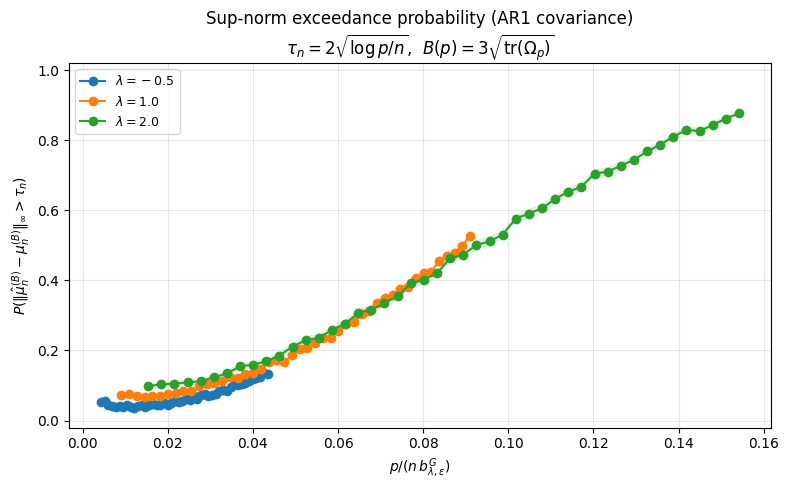

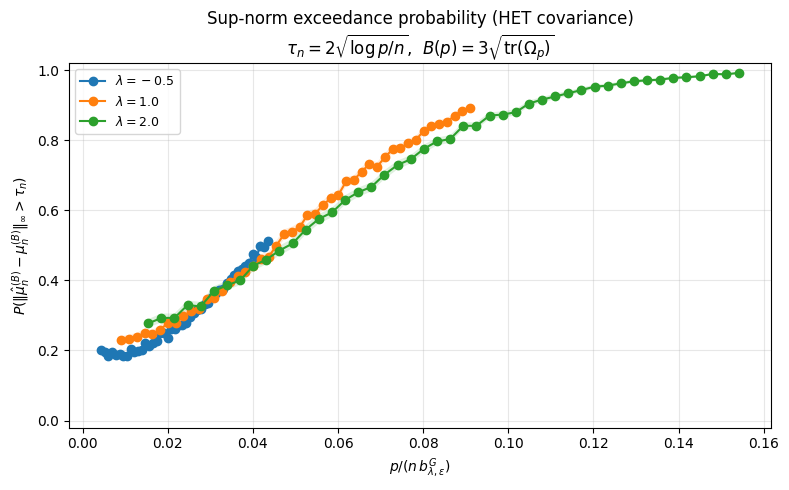

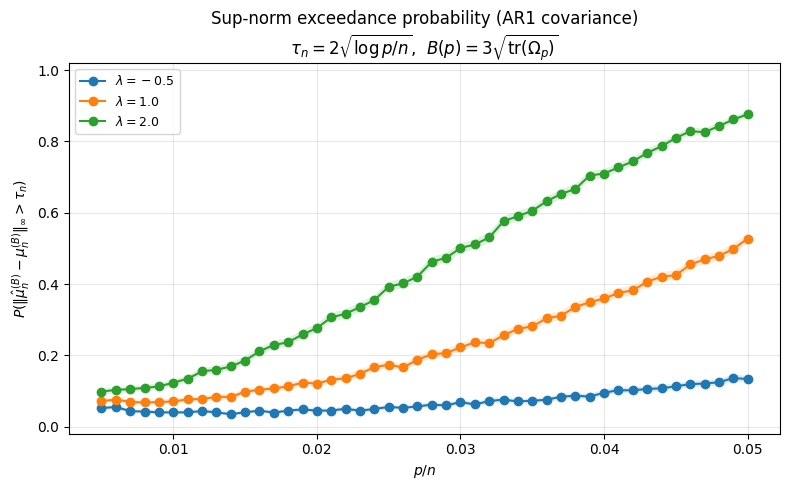

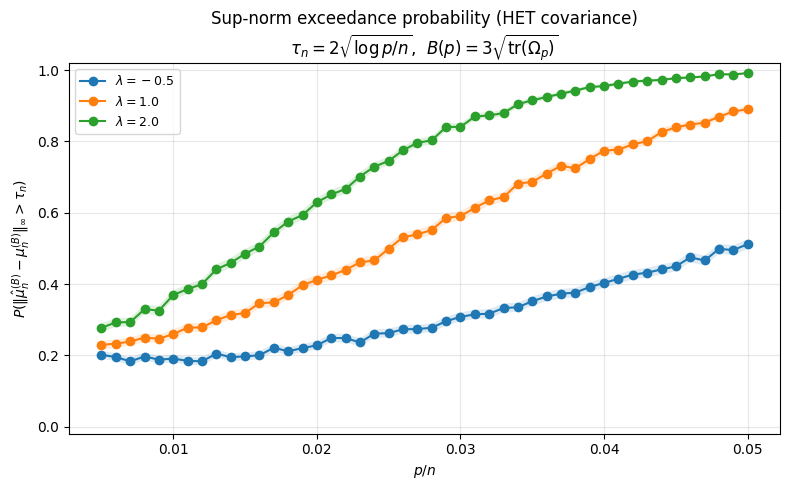

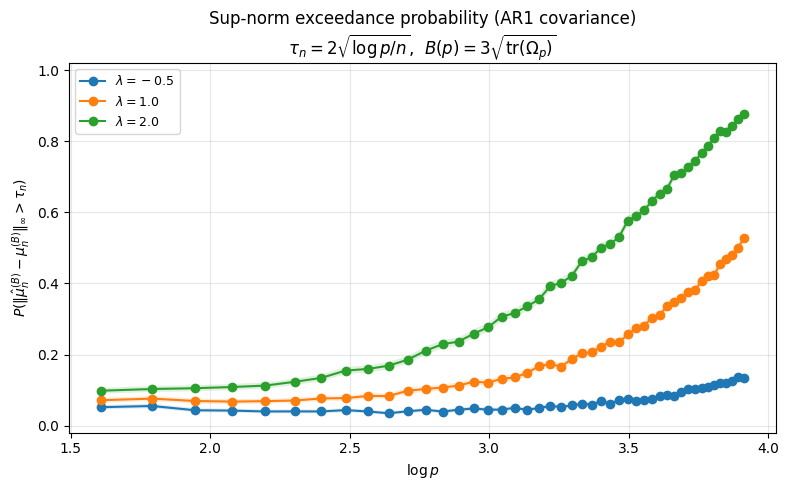

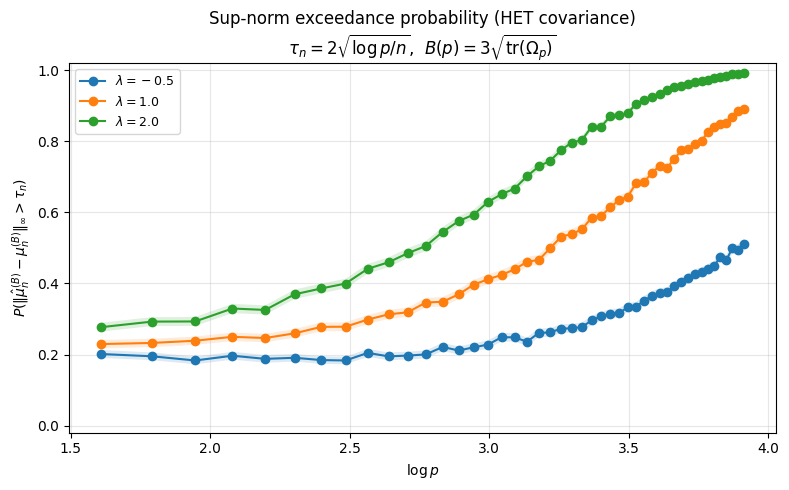

In [3]:
# Block 3: plot sup-norm exceedance probability

from pathlib import Path

def plot_supnorm_exceedance(results_df, lambdas, x_mode="scaled", save_dir="figures"):
    save_dir = Path(save_dir) if save_dir is not None else None
    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)

    for design in ["ar1", "het"]:
        df_design = results_df[results_df["design"] == design].copy()

        plt.figure(figsize=(8, 5))

        for lam in lambdas:
            df_lam = df_design[df_design["lambda"] == lam].sort_values("p")

            if x_mode == "scaled":
                x = df_lam["x_scaled"].to_numpy()
                xlabel = r"$p / (n\, b^G_{\lambda,\epsilon})$"
            elif x_mode == "p_over_n":
                x = (df_lam["p"] / n).to_numpy()
                xlabel = r"$p/n$"
            elif x_mode == "log_p":
                x = np.log(df_lam["p"].to_numpy())
                xlabel = r"$\log p$"
            else:
                raise ValueError("x_mode must be one of 'scaled', 'p_over_n', or 'log_p'.")

            y = df_lam["exceed_prob"].to_numpy()
            se = df_lam["exceed_mc_se"].to_numpy()

            plt.plot(x, y, marker="o", label=fr"$\lambda={lam}$")
            plt.fill_between(
                x,
                np.maximum(0.0, y - 1.96 * se),
                np.minimum(1.0, y + 1.96 * se),
                alpha=0.15
            )

        # if x_mode == "scaled":
        #     plt.axvline(1.0, linestyle=":", linewidth=1.5)

        plt.xlabel(xlabel)
        plt.ylabel(r"$P(\|\hat{\mu}_n^{(B)}-\mu_n^{(B)}\|_\infty > \tau_n)$")
        plt.title(
            f"Sup-norm exceedance probability ({design.upper()} covariance)\n"
            + fr"$\tau_n = {TAU_MULT}\sqrt{{\log p / n}}$,  $B(p)=3\sqrt{{\mathrm{{tr}}(\Omega_p)}}$"
        )
        plt.ylim(-0.02, 1.02)
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=9)
        plt.tight_layout()

        if save_dir is not None:
            plt.savefig(
                save_dir / f"supnorm_exceedance_{design}_{x_mode}.png",
                dpi=300,
                bbox_inches="tight"
            )

        plt.show()


# Save figures into ./figures while displaying them
save_dir = "figures"

# Paper-style x-axis: p / (n b^G_{lambda, eps})
plot_supnorm_exceedance(results_supnorm, lambdas, x_mode="scaled", save_dir=save_dir)

# Optional: also look at p/n on the x-axis
plot_supnorm_exceedance(results_supnorm, lambdas, x_mode="p_over_n", save_dir=save_dir)

# Optional: also look at log p on the x-axis
plot_supnorm_exceedance(results_supnorm, lambdas, x_mode="log_p", save_dir=save_dir)